In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.io as pio
import polars as pl
import scienceplots
import seaborn as sns

from qr.utils import *

sns.set_style("whitegrid")
plt.style.use(["science", "grid", "no-latex"])
pio.templates.default = "plotly_white"

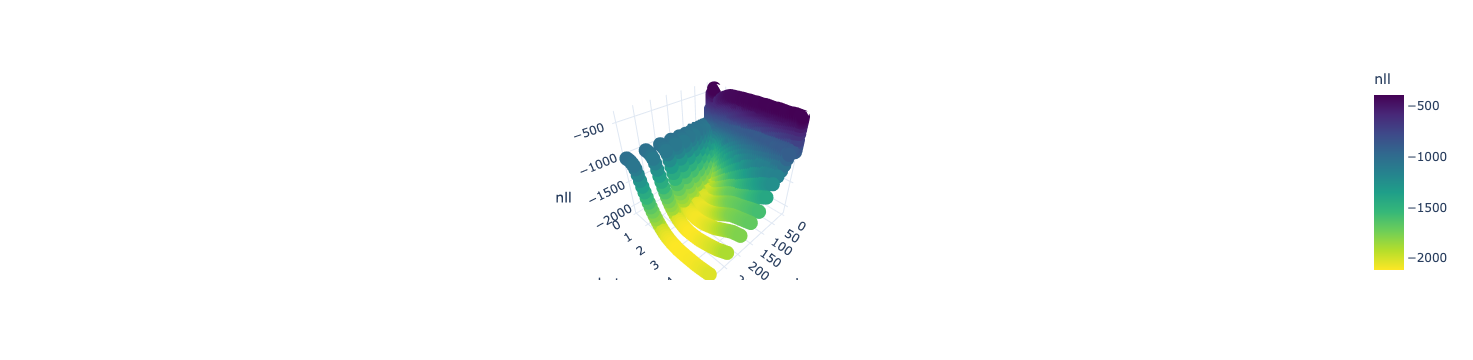

In [2]:
ticker = "PFE"
calibration_result = pl.read_csv(
    Path.home()
    / f"dev_cpp/qr/data/results/{ticker}/impact_calibration/calibration_results.csv"
)
fig = px.scatter_3d(
    calibration_result.to_pandas(),
    x="tau",
    y="beta",
    z="nll",
    color="nll",
    color_continuous_scale="Viridis_r",
)
fig.update_layout(template="plotly_white")
fig.show()

In [3]:
taus = calibration_result["tau"].unique().sort()
betas = calibration_result["beta"].unique().sort()
TAU, BETA = np.meshgrid(taus.to_numpy(), betas.to_numpy())

nll_grid = (
    calibration_result.pivot(on="beta", index="tau", values="nll")
    .drop("tau")
    .to_numpy()
    .T
)

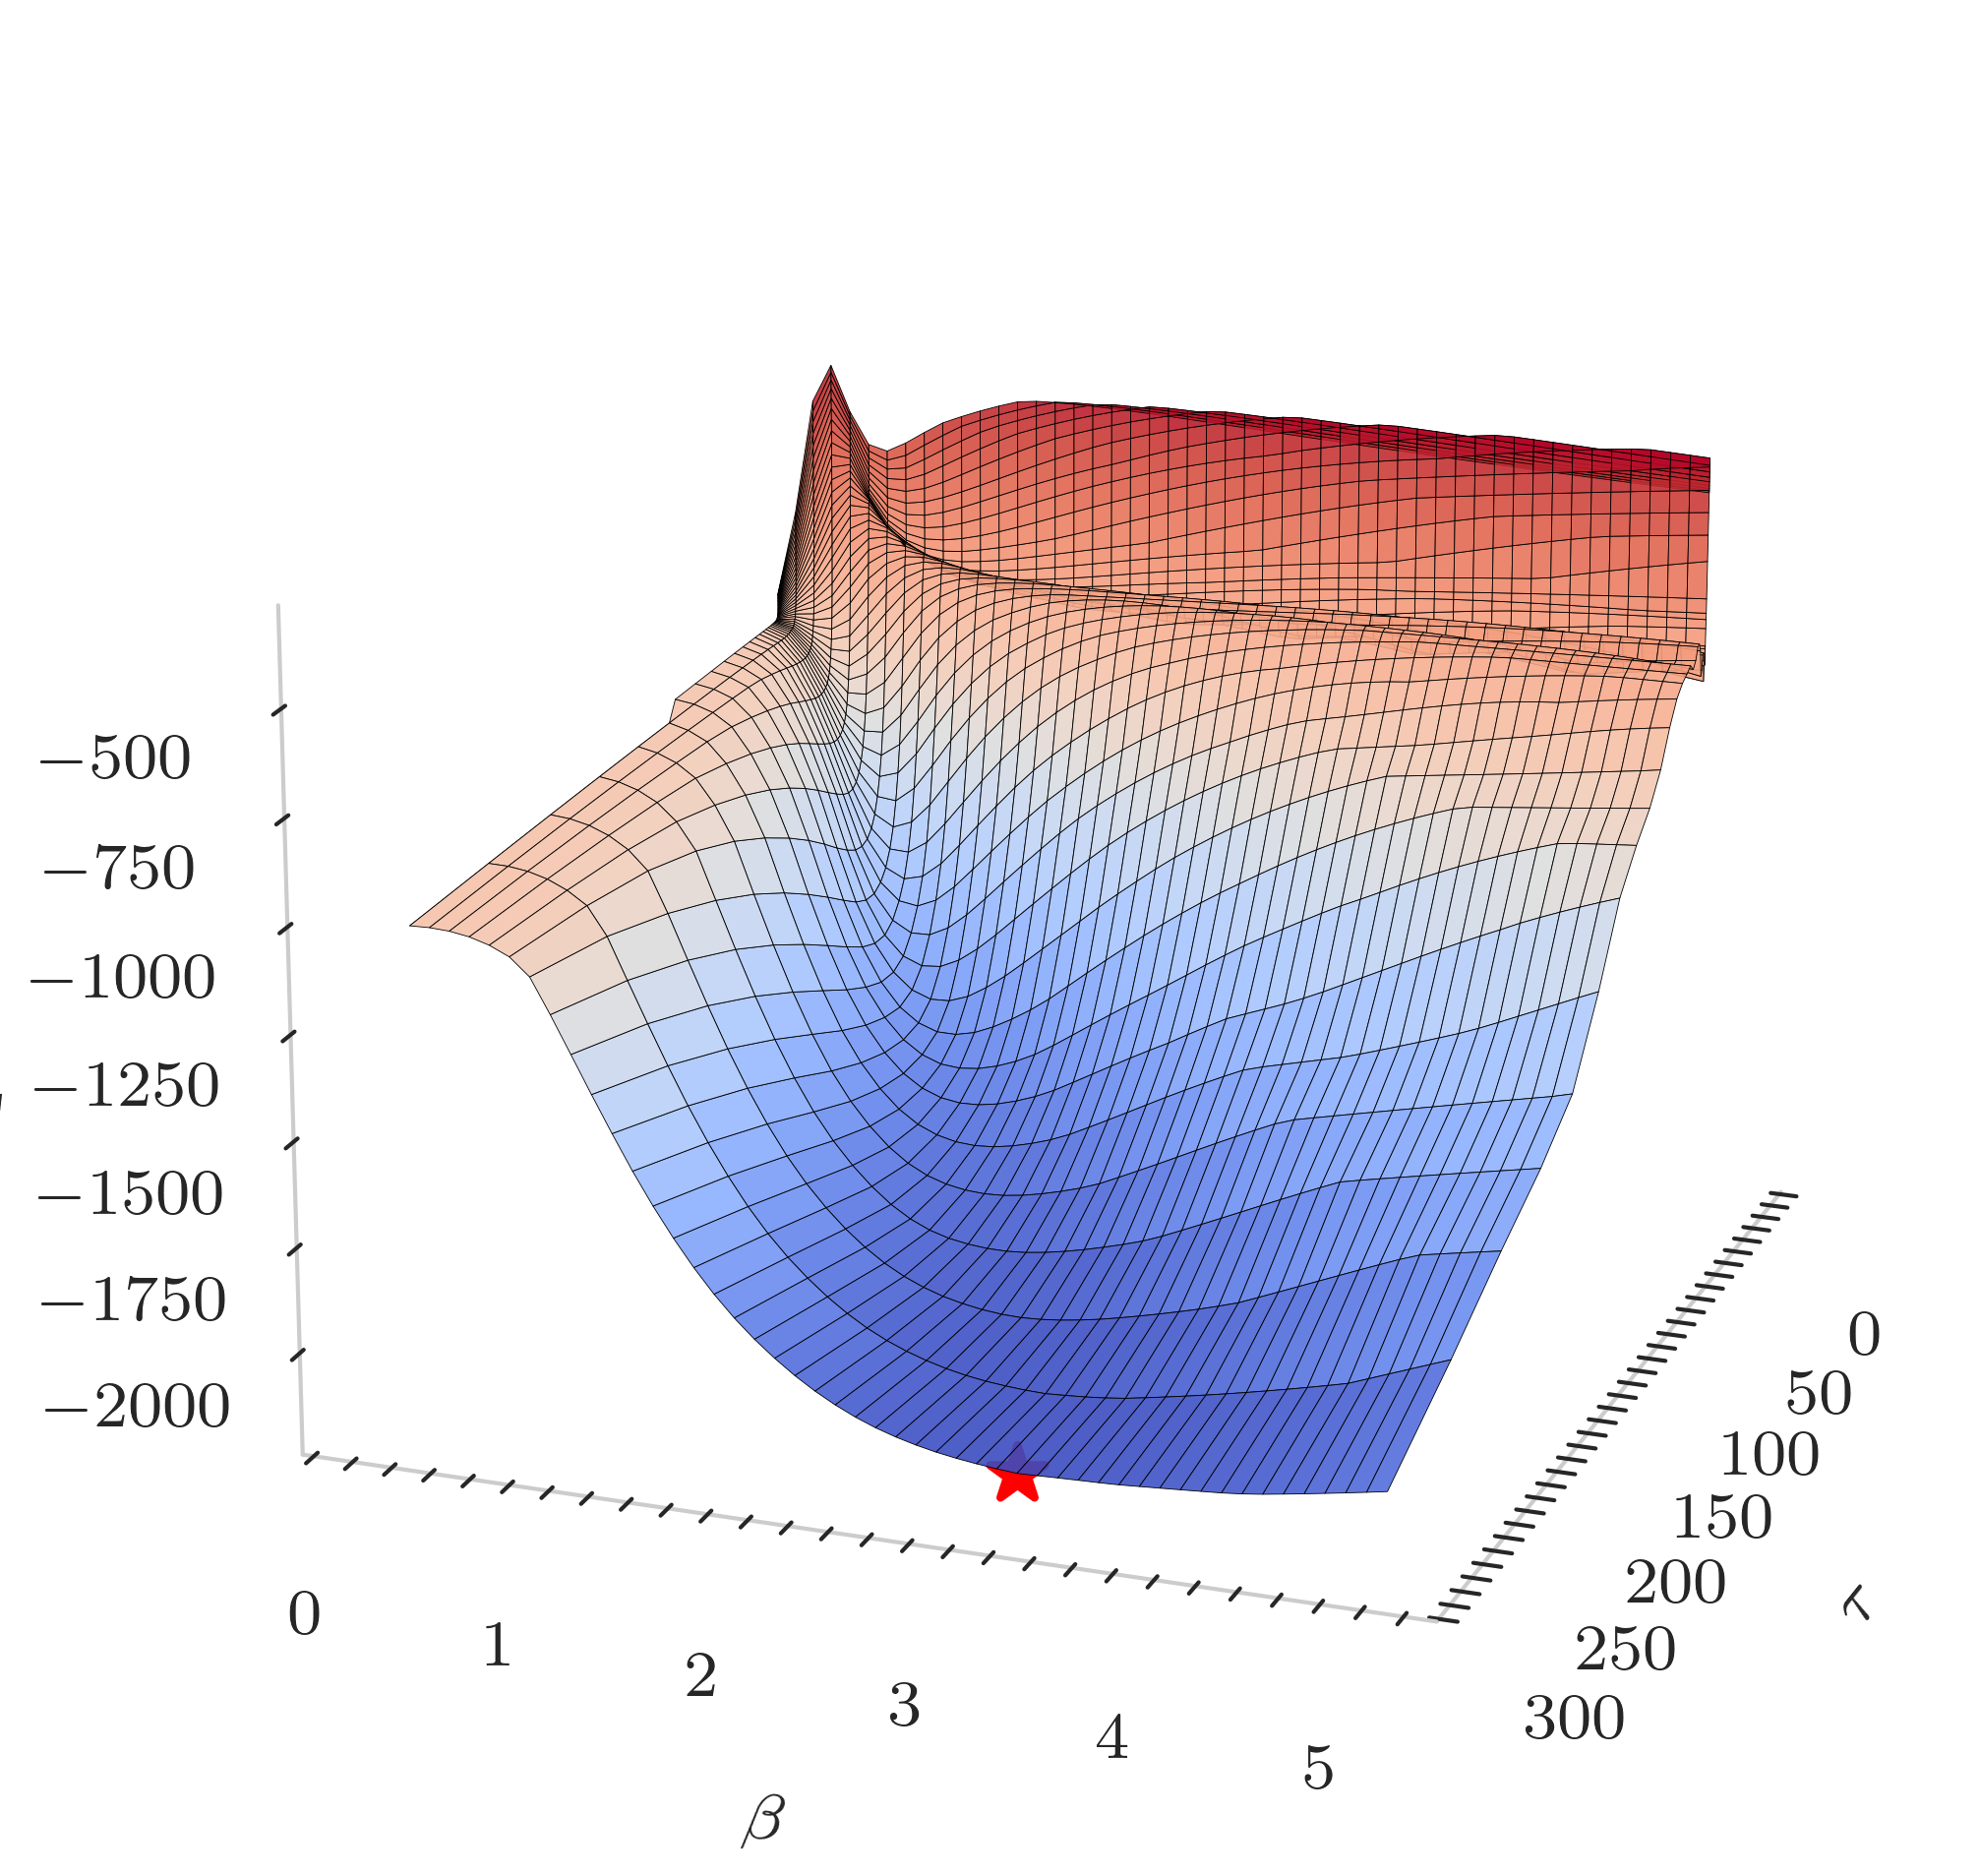

In [4]:
with ieee():
    fig = plt.figure(figsize=(5, 4))
    fig.patch.set_alpha(0)
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        TAU, BETA, nll_grid, cmap="coolwarm", edgecolor="k", linewidth=0.1, alpha=0.9
    )

    min_idx = calibration_result["nll"].arg_min()
    best = calibration_result.row(min_idx, named=True)
    ax.scatter(
        best["tau"], best["beta"], best["nll"], color="r", s=50, marker="*", zorder=10
    )
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("none")
    ax.yaxis.pane.set_edgecolor("none")
    ax.zaxis.pane.set_edgecolor("none")
    ax.grid(False)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\beta$")
    ax.set_zlabel("NLL")
    ax.view_init(elev=20, azim=20)

    # fig.savefig("../../paper/impact_nll.pdf", bbox_inches="tight", transparent=True)
    plt.show()

In [5]:
K = 12
tau = 50
beta = 1.5
half_lives = np.logspace(-2, 3, K)
lambdas = np.log(2) / half_lives
t = np.logspace(-3, 3, 100)

y = (1 + t / tau) ** (-beta)
X = np.exp(-lambdas[None, :] * t[:, None])
w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
w = np.maximum(w, 0)

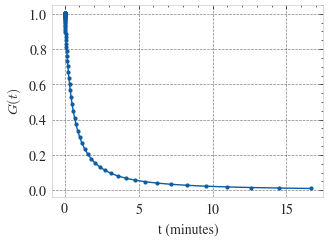

In [6]:
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    ax.plot(t / 60, (w * X).sum(axis=1), marker="o", ms=2)
    ax.set_xlabel("t (minutes)")
    ax.set_ylabel(r"$G(t)$")

    # fig.savefig(f"../../paper/decay_kernel.pdf", bbox_inches="tight")
    plt.show()

In [7]:
K = 12
tau = 300
beta = 3.2
half_lives = np.logspace(-2, 3, K)
lambdas = np.log(2) / half_lives
t = np.logspace(-3, 3, 100)

y = (1 + t / tau) ** (-beta)
X = np.exp(-lambdas[None, :] * t[:, None])
w2, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
w2 = np.maximum(w2, 0)

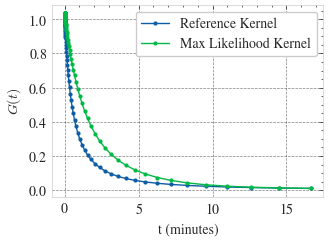

In [8]:
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    fig.patch.set_alpha(0)

    ax.plot(t / 60, (w * X).sum(axis=1), marker="o", ms=2, label="Reference Kernel")
    ax.plot(
        t / 60, (w2 * X).sum(axis=1), marker="o", ms=2, label="Max Likelihood Kernel"
    )
    ax.set_xlabel("t (minutes)")
    ax.set_ylabel(r"$G(t)$")

    ax.legend()
    # fig.savefig(f"../../paper/nll_vs_ref_kernel.pdf", bbox_inches="tight")
    plt.show()